In [2]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

# Make repo root the cwd so format_results' relative paths (results/all_runs_latest.csv,
# analysis/figures) resolve correctly regardless of where you launched Jupyter.
REPO_ROOT = Path.cwd().parent if Path.cwd().name == "analysis" else Path.cwd()
import os
os.chdir(REPO_ROOT)
sys.path.insert(0, str(REPO_ROOT / "analysis"))

from format_results import format_data, MODEL_ORDER, BUCKET_ORDER, CONTRACT_ORDER, FULL_DF, DEFAULT_FONT_SIZE, OUTPUT_FOLDER

In [3]:
import pandas as pd
import numpy as np

import argparse
import os
import pandas as pd
import ast
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import bootstrap
from matplotlib.lines import Line2D

In [4]:
df = format_data(pd.read_csv("results/results_contract_only/all_runs_latest.csv"))

GPT-4.1 has 240 rows.
Formatted data with 1 unique model pairs,  240 total rows


In [5]:
df.head()

,Model Pair,Grid ID,Remapped Grid ID,Config ID,Run ID,System Prompt,Context,Fog of War,Other Player Visible,Grid,Bucket,Sub-stratum,Pay4Partner,Contract Type,Contract Only,Negotiation Internal Reasoning,Total Turns,Format Errors,Format Errors P-Red,Format Errors P-Blue,Format Errors Judge,Non-Cooperative Baseline P-Red,Non-Cooperative Baseline P-Blue,Joint Reward,Reward P-Red,Reward P-Blue,Gini,Max Possible Reward,Reached Goal P-Red,Reached Goal P-Blue,Total Trades Proposed,Total Trades Proposed P-Red,Total Trades Proposed P-Blue,Total Trades Accepted,Total Trades Accepted P-Red,Total Trades Accepted P-Blue,Total Trades Rejected,Total Trades Rejected P-Red,Total Trades Rejected P-Blue,amount_received_by_P-Red_from_trades,amount_received_by_P-Blue_from_trades,total_trades_failed,Total P4P Arrangements Proposed,Total P4P Arrangements Proposed P-Red,Total P4P Arrangements Proposed P-Blue,Total P4P Arrangements Accepted,Total P4P Arrangements Accepted P-Red,Total P4P Arrangements Accepted P-Blue,Total P4P Arrangements Rejected,Total P4P Arrangements Rejected P-Red,Total P4P Arrangements Rejected P-Blue,Total P4P Promises Kept,Total P4P Promises Kept P-Red,Total P4P Promises Kept P-Blue,Total P4P Promises Broken,Total P4P Promises Broken P-Red,Total P4P Promises Broken P-Blue,Total P4P Amounts Promised to Receive,Total P4P Amounts Promised to Receive P-Red,Total P4P Amounts Promised to Receive P-Blue,Total P4P Amounts Received,Total P4P Amounts Received P-Red,Total P4P Amounts Received P-Blue,contract_accepted,contract_negotiaion_length,num_tiles_in_contract,num_tiles_promised_to_receive_from_contract_P-Red,num_tiles_promised_to_receive_from_contract_P-Blue,moves_made_under_strict_contract_P-Red,moves_made_under_strict_contract_P-Blue,contract_moves_blocked_by_partner_shortfall_P-Red,contract_moves_blocked_by_partner_shortfall_P-Blue,points_for_completion_promised_to_P-Red,points_for_completion_promised_to_P-Blue,parity_trades_offered_P-Red,parity_trades_offered_P-Blue,parity_trades_accepted_P-Red,parity_trades_accepted_P-Blue,parity_trades_rejected_P-Red,parity_trades_rejected_P-Blue,extractive_trades_offered_P-Red,extractive_trades_offered_P-Blue,extractive_trades_accepted_P-Red,extractive_trades_accepted_P-Blue,extractive_trades_rejected_P-Red,extractive_trades_rejected_P-Blue,concessionary_trades_offered_P-Red,concessionary_trades_offered_P-Blue,concessionary_trades_accepted_P-Red,concessionary_trades_accepted_P-Blue,concessionary_trades_rejected_P-Red,concessionary_trades_rejected_P-Blue,B Min Trades Path,B Max Trades Path,R Min Trades Path,R Max Trades Path,Trade Asymmetry,Config Label,Model,Board Type,P-Red Has Final Leverage Tile,P-Blue Has Final Leverage Tile,Either Player Has Final Leverage Tile,Both Finished,Normalized Joint Reward,R_beats_baseline,B_beats_baseline,Both Beat Baseline,All Beat Baseline,Both Beat Zero Cooperation Baseline,Proportion of Total Points for P-Red,trade_volume_proportion_P-Red,p4p_volume_proportion_P-Red,strict_contract_tile_proportion_P-Red,net_tiles_promised_to_receive_from_contract_P-Red,net_tiles_promised_to_receive_from_contract_P-Blue,strict_tile_gini,strict_tile_even_split,strict_tile_winner_take_all,contract_for_finishing_points_proportion_P-Red,contract_for_finishing_points_gini,contract_for_finishing_points_even_split,contract_for_finishing_points_winner_take_all,net_points_for_completion_promised_to_P-Red,net_points_for_completion_promised_to_P-Blue,Contract Gini,Contract Even Split,Contract Winner Take All,Contract Net P-Red,total_trade_volume,Trade Volume,trade_acceptance_rate_P-Red,trade_acceptance_rate_P-Blue,total_trade_acceptance_rate,moves_made_under_strict_contract_total,Moves Made Under Strict Contract,parity_trade_acceptance_rate,extractive_trades_acceptance_rate,concessionary_trades_acceptance_rate,Bad Trade,P4P Promise Honour Rate P-Red,P4P Promise Honour Rate P-Blue,Total P4P Promise Honour Rate,Defection Rate,Defection Volume
0,FOUR_1-FOUR_1,80,20,ctx1_fog00_p4ptrue_cont

In [6]:
df['Negotiation Internal Reasoning'].value_counts()

Negotiation Internal Reasoning
True    240
Name: count, dtype: int64

In [7]:
def plot_panels_visibility_per_model(
    df: pd.DataFrame,
    board_types: list[str],
    contract_order: list[str],
    metrics: list[str] | str = "Both Finished",
    output_folder: str = OUTPUT_FOLDER,
    figsize: tuple[float, float] | None = None,
    rotate_xticks: int = 0,
    abbreviate_x_labels: bool = False,
    metric_name_mapping: dict[str, str] | None = None,
):
    """
    One subplot per metric. Per (Board Type, Contract Type, Visibility) compute
    mean + 95% CI across grids/runs and plot as a single marker with error bars.
      - Color  = Board Type (same palette as plot_panels_boards_overlaid)
      - Marker = Visibility (Hidden vs Visible) — assumes ~one model
    """
    import os
    from matplotlib.lines import Line2D

    if isinstance(metrics, str):
        metrics = [metrics]
    n_panels = len(metrics)

    # Normalize Other Player Visible (stored as list or stringified list)
    def _norm_opv(v):
        s = str(v).lower()
        if "true" in s and "false" not in s:
            return "Visible"
        if "false" in s and "true" not in s:
            return "Hidden"
        return None

    RT = df.copy()
    RT["Visibility"] = RT["Other Player Visible"].apply(_norm_opv)
    RT = RT[RT["Visibility"].isin(["Hidden", "Visible"])].copy()
    RT = RT[RT["Board Type"].isin(board_types)].copy()
    RT["Contract Type"] = pd.Categorical(RT["Contract Type"], categories=contract_order, ordered=True)

    for m in metrics:
        if m not in RT.columns:
            raise ValueError(f"Missing metric column: {m}")

    x_labels = (
        {"No Contract": "NC", "Prog-Points": "PP", "NL-Trading": "NLT", "Prog-Trading": "PT"}
        if abbreviate_x_labels else {ct: ct for ct in contract_order}
    )

    # Same color palette as plot_panels_boards_overlaid
    default_bucket_colors = {
        "Independent": "tab:green",
        "Mutually Dependent": "tab:purple",
        "Asymmetric": "tab:red",
    }
    bucket_to_color = {b: default_bucket_colors.get(b, "tab:gray") for b in board_types}

    visibility_order = ["Hidden", "Visible"]
    visibility_to_marker = {"Hidden": "X", "Visible": "o"}

    # Use the single model's display name for the legend (e.g. "GPT-4.1")
    models_present = sorted(RT["Model"].dropna().unique().tolist())
    model_label = models_present[0] if len(models_present) == 1 else "/".join(models_present)

    xpos = {ct: i for i, ct in enumerate(contract_order)}

    long = RT.melt(
        id_vars=["Board Type", "Contract Type", "Visibility", "Grid ID"],
        value_vars=metrics, var_name="Metric", value_name="Value",
    )

    stats = (
        long.groupby(["Board Type", "Contract Type", "Visibility", "Metric"], observed=True)
            .agg(mean=("Value", "mean"), sd=("Value", "std"), n=("Value", "count"))
            .reset_index()
    )
    stats["sem"] = stats["sd"] / np.sqrt(stats["n"])
    stats["ci95"] = 1.96 * stats["sem"]
    stats.loc[stats["n"] <= 1, "ci95"] = 0.0

    # x-jitter: outer offset = board type, inner offset = visibility
    bucket_span = 0.22
    bucket_offsets = [0.0] if len(board_types) == 1 else list(np.linspace(-bucket_span, bucket_span, num=len(board_types)))
    bucket_to_offset = dict(zip(board_types, bucket_offsets))

    vis_span = 0.07
    vis_offsets = list(np.linspace(-vis_span, vis_span, num=len(visibility_order)))
    visibility_to_offset = dict(zip(visibility_order, vis_offsets))

    if figsize is None:
        figsize = (5 * n_panels + 2, 6)

    fig, axes = plt.subplots(nrows=1, ncols=n_panels, figsize=figsize, sharex=True, squeeze=False)
    axes = axes[0]

    for panel_idx, metric in enumerate(metrics):
        ax = axes[panel_idx]
        ms = stats[stats["Metric"] == metric]

        for b in board_types:
            for v in visibility_order:
                d = ms[(ms["Board Type"] == b) & (ms["Visibility"] == v)]
                if d.empty:
                    continue
                xs = (
                    d["Contract Type"].map(xpos).to_numpy()
                    + bucket_to_offset[b] + visibility_to_offset[v]
                )
                ys = d["mean"].to_numpy()
                yerr = np.nan_to_num(d["ci95"].to_numpy(), nan=0.0)

                ax.errorbar(
                    xs, ys, yerr=yerr, fmt="none",
                    ecolor=bucket_to_color[b], elinewidth=1.2,
                    capsize=4, capthick=1.4, alpha=0.95, zorder=4,
                )
                ax.scatter(
                    xs, ys, s=140,
                    marker=visibility_to_marker[v],
                    color=bucket_to_color[b],
                    alpha=1.0, edgecolors="k", linewidths=0.8, zorder=6,
                )

        title = metric_name_mapping.get(metric, metric) if metric_name_mapping else metric
        ax.set_title(title, fontsize=1.15 * DEFAULT_FONT_SIZE, fontweight="bold", pad=8)
        ax.set_ylabel("")
        ax.tick_params(axis="y", labelsize=0.85 * DEFAULT_FONT_SIZE)
        ax.grid(axis="y", alpha=0.15)
        ax.set_xticks(range(len(contract_order)))
        ax.set_xticklabels(
            [x_labels.get(ct, ct) for ct in contract_order],
            rotation=rotate_xticks, ha="center", fontsize=DEFAULT_FONT_SIZE,
        )

    # Legends
    bucket_handles = [
        Line2D([0], [0], marker="o", linestyle="None",
               markerfacecolor=bucket_to_color[b], markeredgecolor="k",
               markersize=10, label=b)
        for b in board_types
    ]
    visibility_handles = [
        Line2D([0], [0], marker=visibility_to_marker[v], linestyle="None",
               markerfacecolor="0.65", markeredgecolor="k",
               markersize=10, label=f"Other Player's State: {v}")
        for v in visibility_order
    ]

    fig.subplots_adjust(bottom=0.22, left=0.06, right=0.98, wspace=0.25)
    fig.legend(handles=bucket_handles, loc="lower center",
               bbox_to_anchor=(0.5, 0.05), ncol=len(bucket_handles),
               fontsize=DEFAULT_FONT_SIZE, frameon=False,
               handletextpad=0.4, columnspacing=1.5, title="Board Type",)
    fig.legend(handles=visibility_handles, loc="lower center",
               bbox_to_anchor=(0.5, 0.0), ncol=len(visibility_handles),
               fontsize=DEFAULT_FONT_SIZE, frameon=False,
               handletextpad=0.4, columnspacing=1.5, title="")

    metrics_str = "_".join(m.replace(" ", "_") for m in metrics)
    os.makedirs(output_folder, exist_ok=True)
    output_path = f"{output_folder}/visibility_per_boardtype_{metrics_str}_panels.pdf"
    fig.savefig(output_path, format="pdf", bbox_inches="tight")
    print(f"Saved figure to {output_path}")


/var/folders/v4/m284bsbd28v34f76996xhy_w0000gn/T/ipykernel_17797/3367854378.py:38: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  RT["Contract Type"] = pd.Categorical(RT["Contract Type"], categories=contract_order, ordered=True)


Saved figure to analysis/figures/visibility_per_boardtype_net_points_for_completion_promised_to_P-Red_net_tiles_promised_to_receive_from_contract_P-Red_panels.pdf


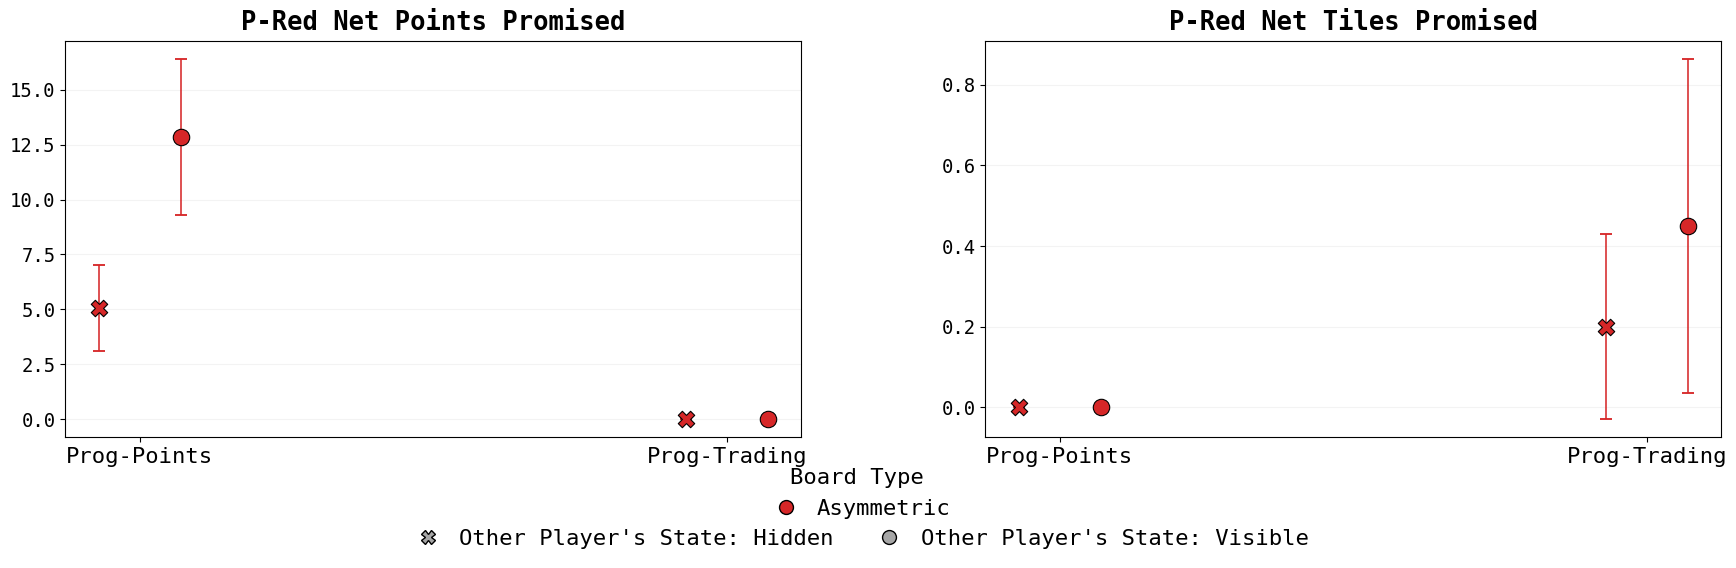

In [8]:
plot_panels_visibility_per_model(
    df=df,
    board_types=["Asymmetric"],
    contract_order=['Prog-Points', 'Prog-Trading'],
    metrics=['net_points_for_completion_promised_to_P-Red', 'net_tiles_promised_to_receive_from_contract_P-Red'],
    figsize=(18, 6),
    metric_name_mapping={
        'net_points_for_completion_promised_to_P-Red': 'P-Red Net Points Promised',
        'net_tiles_promised_to_receive_from_contract_P-Red': 'P-Red Net Tiles Promised',
    }
)


Saved figure to analysis/figures/visibility_per_boardtype_Contract_Even_Split_panels.pdf


/var/folders/v4/m284bsbd28v34f76996xhy_w0000gn/T/ipykernel_17797/3367854378.py:38: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  RT["Contract Type"] = pd.Categorical(RT["Contract Type"], categories=contract_order, ordered=True)


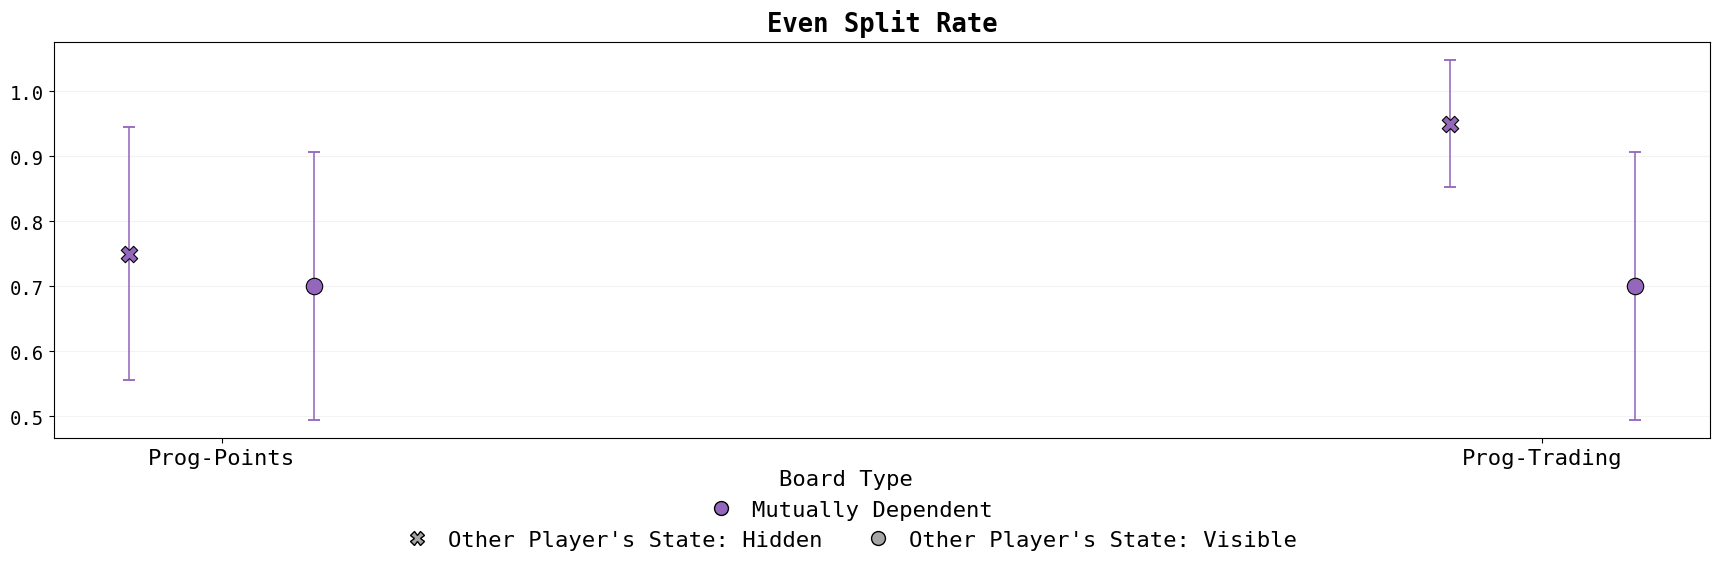

In [9]:
plot_panels_visibility_per_model(
    df=df,
    board_types=["Mutually Dependent"],
    contract_order=['Prog-Points', 'Prog-Trading'],
    metrics=['Contract Even Split'],
    figsize=(18, 6),
    metric_name_mapping={
        'contract_accepted': 'Acceptance Rate',
        'contract_negotiaion_length': 'Negotiation Length',
        'Contract Gini': 'Contract Gini',
        'Contract Even Split': 'Even Split Rate',
        'Contract Winner Take All': 'Winner Takes All Rate',
    }
)


In [10]:
df['Other Player Visible'].value_counts()

Other Player Visible
[True, True]      120
[False, False]    120
Name: count, dtype: int64

In [14]:
from tests_for_significance import test_for_significant_difference

pp_asymmetric = df[(df['Contract Type'] == 'Prog-Points') & (df['Board Type'] == 'Asymmetric')].copy()
hidden_state = pp_asymmetric[pp_asymmetric['Other Player Visible'] == '[False, False]']['net_points_for_completion_promised_to_P-Red']
visible_state = pp_asymmetric[pp_asymmetric['Other Player Visible'] == '[True, True]']['net_points_for_completion_promised_to_P-Red']

test_for_significant_difference(hidden_state, visible_state)

  Mann-Whitney U = 101.5,  p = 0.003684
  Welch t-test   t = -3.778,  p = 0.000271

  ✓ Significant at α=0.05 (Mann-Whitney)


In [15]:
print("Hidden state mean:", hidden_state.mean())
print("Visible state mean:", visible_state.mean())

Hidden state mean: 5.05
Visible state mean: 12.85


In [16]:
pt_asymmetric = df[(df['Contract Type'] == 'Prog-Trading') & (df['Board Type'] == 'Asymmetric')].copy()
hidden_state_pt = pt_asymmetric[pt_asymmetric['Other Player Visible'] == '[False, False]']['net_tiles_promised_to_receive_from_contract_P-Red']
visible_state_pt = pt_asymmetric[pt_asymmetric['Other Player Visible'] == '[True, True]']['net_tiles_promised_to_receive_from_contract_P-Red']
test_for_significant_difference(hidden_state_pt, visible_state_pt)

  Mann-Whitney U = 185.5,  p = 0.2835
  Welch t-test   t = -1.035,  p = 0.1535

  ✗ Not significant at α=0.05 (Mann-Whitney)


In [18]:
print("Hidden state mean:", hidden_state_pt.mean())
print("Visible state mean:", visible_state_pt.mean())

Hidden state mean: 0.2
Visible state mean: 0.45


In [20]:
pt_mutually_dependent = df[(df['Contract Type'] == 'Prog-Trading') & (df['Board Type'] == 'Mutually Dependent')].copy()
hidden_state_pt_md = pt_mutually_dependent[pt_mutually_dependent['Other Player Visible'] == '[False, False]']['Contract Even Split']
visible_state_pt_md = pt_mutually_dependent[pt_mutually_dependent['Other Player Visible'] == '[True, True]']['Contract Even Split']
test_for_significant_difference(hidden_state_pt_md, visible_state_pt_md)

  Mann-Whitney U = 250.0,  p = 0.981
  Welch t-test   t = 2.147,  p = 0.9809

  ✗ Not significant at α=0.05 (Mann-Whitney)


In [21]:
print("Hidden state mean:", hidden_state_pt_md.mean())
print("Visible state mean:", visible_state_pt_md.mean())

Hidden state mean: 0.95
Visible state mean: 0.7


In [22]:
pp_mutually_dependent = df[(df['Contract Type'] == 'Prog-Points') & (df['Board Type'] == 'Mutually Dependent')].copy()
hidden_state_pp_md = pp_mutually_dependent[pp_mutually_dependent['Other Player Visible'] == '[False, False]']['Contract Even Split']
visible_state_pp_md = pp_mutually_dependent[pp_mutually_dependent['Other Player Visible'] == '[True, True]']['Contract Even Split']
test_for_significant_difference(hidden_state_pp_md, visible_state_pp_md)

  Mann-Whitney U = 210.0,  p = 0.6432
  Welch t-test   t = 0.346,  p = 0.6343

  ✗ Not significant at α=0.05 (Mann-Whitney)


In [23]:
print("Hidden state mean:", hidden_state_pp_md.mean())
print("Visible state mean:", visible_state_pp_md.mean())

Hidden state mean: 0.75
Visible state mean: 0.7
